In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heartdisease/heart.csv


In [2]:
import warnings
# Suppressing a warning 
warnings.filterwarnings("ignore") 

# It is a magic function that renders the figure in the notebook
%matplotlib inline 

import seaborn as sns
# Changing the figure size of a seaborn axes 
sns.set(rc={"figure.figsize": (20, 15)})

# The style parameters control properties like the color of the background and whether a grid is enabled by default.
sns.set_style("white")
#styledict, or one of {darkgrid, whitegrid, dark, white, ticks}

<p style="background-color:#blue;color:black;font-size:20px;text-align:center;border-radius:10px 10px;font-weight:bold;border:2px solid black;"> Heart Attack Risk Prediction Using PyCaret Library (AutoML) <span style='font-size:28px; background-color:blue ;'>  </span></p>

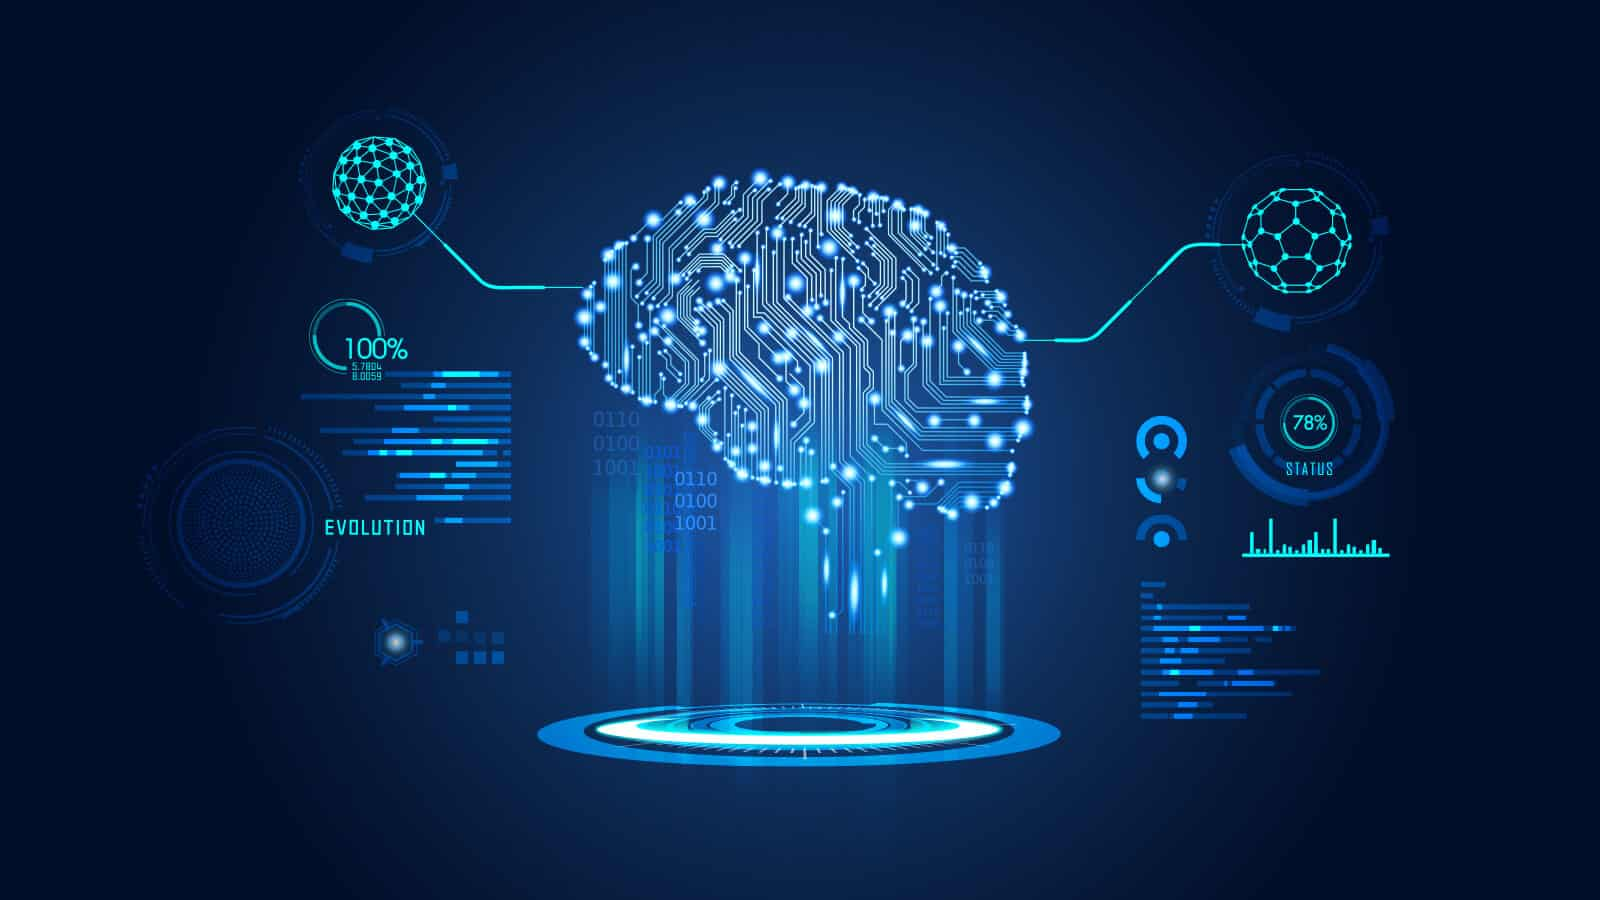

# <p style="background-color:#blue;color:black;font-size:20px;text-align:center;border-radius:10px 10px;font-weight:bold;border:2px solid black;"> 🎯 LEARNING GOALS 🎯 <span style='font-size:28px; background-color:blue ;'>  </span></p>

In this part 2 of our Machine Learning journey, we delve into the world of automated machine learning (**AutoML**) techniques using **PyCaret**. Here are the goals of this analysis:

* Streamline model selection and hyperparameter tuning using PyCaret's advanced features:
    - Automated feature engineering
    - Algorithm selection
    - Hyperparameter optimization
    - Model evaluation
    
    
* Leverage PyCaret Library to enhance models and find the optimal solution for predicting heart attack risk.

Without further ado, let's dive straight in ! 👨‍💻✨


# <p style="background-color:#blue;color:black;font-size:20px;text-align:center;border-radius:10px 10px;font-weight:bold;border:2px solid black;"> 🚀 ONBOARDING 🚀<span style='font-size:28px; background-color:blue ;'>  </span></p>

**PyCaret** is a Python library for simplified machine learning. It automates tasks like data preprocessing, feature selection, model training, and hyperparameter tuning. It offers an easy-to-use interface and supports various algorithms and model evaluation techniques. 

It's great for quick experimentation and deployment of machine learning models. 

Let's install PyCaret !

In [3]:
# Installing Pycaret
!pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.7/484.7 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.4/153.4 kB 17.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - \ done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 15.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.1/70.1 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.0/17.0 MB 47.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 50.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 61.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 20.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.2/118.2 kB 11.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 10.2 

PyCaret library simplifies the machine learning workflow by automating essential preprocessing techniques and data splitting. 

It takes care of tasks such as feature encoding, missing value imputation, and data partitioning, allowing us to focus on the core aspects of our analysis.

In [4]:
from pycaret.classification import *

Let's import our dataset.

In [5]:
df = pd.read_csv("/kaggle/input/heartdisease/heart.csv")
df = df.drop(['oldpeak','slp','thall'],axis=1)
df.head(10)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa,output
0,63,1,3,145,233,1,0,150,0,0,1
1,37,1,2,130,250,0,1,187,0,0,1
2,41,0,1,130,204,0,0,172,0,0,1
3,56,1,1,120,236,0,1,178,0,0,1
4,57,0,0,120,354,0,1,163,1,0,1
5,57,1,0,140,192,0,1,148,0,0,1
6,56,0,1,140,294,0,0,153,0,0,1
7,44,1,1,120,263,0,1,173,0,0,1
8,52,1,2,172,199,1,1,162,0,0,1
9,57,1,2,150,168,0,1,174,0,0,1


The code below initializes the PyCaret setup by importing the necessary module and setting up the data and target variable. 

After executing this code, PyCaret will preprocess the data, split it into training and testing sets, and set up the environment for model training and evaluation. 

In [6]:
# Importing module and initializing setup
model = setup(data = df, target = 'output')

,Description,Value
0,Session id,8823
1,Target,output
2,Target type,Binary
3,Original data shape,"(303, 11)"
4,Transformed data shape,"(303, 11)"
5,Transformed train set shape,"(212, 11)"
6,Transformed test set shape,"(91, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


# <p style="background-color:#blue;color:black;font-size:20px;text-align:center;border-radius:10px 10px;font-weight:bold;border:2px solid black;"> 🥇 AUTOMATED ALGORITHM SELECTION 🥇 <span style='font-size:28px; background-color:blue ;'>  </span></p>

We can then proceed with training and comparing different models using PyCaret's functions and methods.

In [7]:
# Compare the performance of all available classification models
compare_models()

# By default, the models are evaluated using cross-validation and multiple performance metrics.
# The output will display the performance results of each model.

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8061,0.8863,0.8409,0.8201,0.8246,0.6033,0.6148,0.5670
lr,Logistic Regression,0.7922,0.8787,0.8432,0.8027,0.8193,0.5748,0.5813,0.4940
ridge,Ridge Classifier,0.7874,0.0000,0.8523,0.7923,0.8177,0.5644,0.5723,0.0530
lda,Linear Discriminant Analysis,0.7874,0.8778,0.8523,0.7923,0.8177,0.5644,0.5723,0.0640
qda,Quadratic Discriminant Analysis,0.7831,0.8504,0.8348,0.7938,0.8056,0.5561,0.5718,0.0610
rf,Random Forest Classifier,0.7781,0.8604,0.8159,0.7907,0.7979,0.5488,0.5600,0.5030
catboost,CatBoost Classifier,0.7729,0.8748,0.8152,0.7834,0.7947,0.5369,0.5466,1.2400
lightgbm,Light Gradient Boosting Machine,0.7647,0.8574,0.7909,0.7780,0.7781,0.5249,0.5348,0.2820
gbc,Gradient Boosting Classifier,0.7636,0.8468,0.8068,0.7708,0.7848,0.5196,0.5268,0.3110
ada,Ada Boost Classifier,0.7587,0.8206,0.8083,0.7649,0.7845,0.5104,0.5139,0.2900


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     n_estimators=100, n_jobs=-1, oob_score=False,
                     random_state=8823, verbose=0, warm_start=False)

CatBoost, the winnerof this models comparison task, is a powerful gradient boosting algorithm for handling categorical features effectively and automatically handling missing values. 

The high Kappa score indicates good model performance, but it's important to consider the class imbalance in the dataset, specifically with the "Sex" variable. 

Class imbalance can affect model evaluation, and additional techniques like oversampling or undersampling may be needed to address this issue and improve performance.

Based on the model obtained in Part 1, we shall proceed with the Random Forest model, which comes second in this case.

In [8]:
# Displaying the best performing model for further analysis
random_forest = create_model('rf')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8636,0.9625,1.0000,0.8000,0.8889,0.7179,0.7483
1,0.7273,0.8125,0.7500,0.7500,0.7500,0.4500,0.4500
2,0.7619,0.8889,0.9167,0.7333,0.8148,0.4928,0.5173
3,0.7143,0.8611,0.6667,0.8000,0.7273,0.4324,0.4404
4,0.7619,0.8657,0.9167,0.7333,0.8148,0.4928,0.5173
5,0.7619,0.8318,0.7273,0.8000,0.7619,0.5249,0.5273
6,0.9048,0.9318,0.9091,0.9091,0.9091,0.8091,0.8091
7,0.7619,0.7727,0.7273,0.8000,0.7619,0.5249,0.5273
8,0.8095,0.9455,0.7273,0.8889,0.8000,0.6216,0.6331


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

# <p style="background-color:#blue;color:black;font-size:20px;text-align:center;border-radius:10px 10px;font-weight:bold;border:2px solid black;"> 🛠️ HYPERPARAMETER OPTIMIZATION 🛠️ <span style='font-size:28px; background-color:blue ;'>  </span></p>

In [9]:
random_forest

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       n_estimators=100, n_jobs=-1, oob_score=False,
                       random_state=8823, verbose=0, warm_start=False)

We may also hypertune our model in order to get potentially a higher accuracy.

In [10]:
tuned_model = tune_model(random_forest)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9091,0.9250,1.0000,0.8571,0.9231,0.8136,0.8281
1,0.7273,0.8583,0.6667,0.8000,0.7273,0.4590,0.4667
2,0.7619,0.8796,0.9167,0.7333,0.8148,0.4928,0.5173
3,0.8571,0.9352,0.7500,1.0000,0.8571,0.7200,0.7500
4,0.7619,0.8611,0.9167,0.7333,0.8148,0.4928,0.5173
5,0.7619,0.8273,0.7273,0.8000,0.7619,0.5249,0.5273
6,0.8571,0.9364,0.8182,0.9000,0.8571,0.7149,0.7182
7,0.7619,0.8364,0.7273,0.8000,0.7619,0.5249,0.5273
8,0.8571,0.9727,0.7273,1.0000,0.8421,0.7175,0.7480


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


# <p style="background-color:#blue;color:black;font-size:20px;text-align:center;border-radius:10px 10px;font-weight:bold;border:2px solid black;"> 🕵️‍♂️ PREDICTION 🕵️‍♂️ <span style='font-size:28px; background-color:blue ;'>  </span></p>

Finally to close this cahpter, let's now make some predictions on a test dataset. 🔭

In [11]:
x= df.iloc[:,:-1]
x

from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder object
lbl = LabelEncoder()

# Transform the target variable
y = df.iloc[:, -1:]
y = lbl.fit_transform(y)


from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

pred_holdout = predict_model(random_forest,data= x_test)

pred_holdout

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa,prediction_label,prediction_score
179,57,1,0,150,276,0,0,112,1,1,0,0.97
228,59,1,3,170,288,0,0,159,0,0,1,0.65
111,57,1,2,150,126,1,1,173,0,1,1,0.61
246,56,0,0,134,409,0,0,150,1,2,0,0.67
60,71,0,2,110,265,1,0,130,0,1,1,0.80
...,...,...,...,...,...,...,...,...,...,...,...,...
250,51,1,0,140,298,0,1,122,1,3,0,0.93
19,69,0,3,140,239,0,1,151,0,2,1,0.66
143,67,0,0,106,223,0,1,142,0,2,1,0.68
79,58,1,2,105,240,0,0,154,1,0,1,0.94


I'm glad you enjoyed this journey as much as I did! I'll be here, ready to assist you with more exciting endeavors in the future. Stay tuned for further explorations and discoveries together! ✨

Let's keep up the great work! 😉

The End ! ✅